In [1]:
using DrWatson
@quickactivate "project"
using DifferentialEquations
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using Statistics
using FFTW

script_name = splitext(basename(PROGRAM_FILE))[1]
mkpath(plotsdir(script_name))
mkpath(datadir(script_name))

"/home/vvmalyuga/work/study/2026-1/2026-1==study--simulation-modeling/labs/lab02/project/data"

Описание модели Лотки-Вольтерры

In [2]:
"""
Модель Лотки-Вольтерры (хищник-жертва)
Система уравнений:
dx/dt = αx - βxy # Изменение популяции жертв
dy/dt = δxy - γy # Изменение популяции хищников

Где:
x - популяция жертв (например, зайцы)
y - популяция хищников (например, лисы)
α - естественный прирост жертв (в отсутствие хищников)
β - коэффициент поедания жертв хищниками
δ - коэффициент прироста хищников за счет поедания жертв
γ - естественная смертность хищников (в отсутствие жертв)
"""

function lotka_volterra!(du, u, p, t)
    x, y = u # x - жертвы, y - хищники
    α, β, δ, γ = p # параметры модели
    @inbounds begin
        du[1] = α*x - β*x*y # уравнение для жертв
        du[2] = δ*x*y - γ*y # уравнение для хищников
    end
    nothing
end

lotka_volterra! (generic function with 1 method)

Параметры модели и начальные условия
Классические параметры из литературы

In [3]:
p_lv = [0.1, # α: скорость размножения жертв
        0.02, # β: скорость поедания жертв хищниками
        0.01, # δ: коэффициент конверсии пищи (жертв) в хищников
        0.3] # γ: смертность хищников

4-element Vector{Float64}:
 0.1
 0.02
 0.01
 0.3

Начальные условия: [жертвы, хищники]

In [4]:
u0_lv = [40.0, 9.0] # начальная популяция

2-element Vector{Float64}:
 40.0
  9.0

Временные параметры

In [5]:
tspan_lv = (0.0, 200.0) # длительность симуляции
dt_lv = 0.01 # шаг интегрирования

0.01

Создание и решение задачи

In [6]:
prob_lv = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_lv)
sol_lv = solve(prob_lv,
    Tsit5(), # Метод 5-го порядка
    reltol=1e-8, # Относительная точность
    abstol=1e-10, # Абсолютная точность
    saveat=0.1 # Сохраняем каждые 0.1 единицы времени
)

retcode: Success
Interpolation: 1st order linear
t: 2001-element Vector{Float64}:
   0.0
   0.1
   0.2
   0.3
   0.4
   0.5
   0.6
   0.7
   0.8
   0.9
   1.0
   1.1
   1.2
   ⋮
 198.9
 199.0
 199.1
 199.2
 199.3
 199.4
 199.5
 199.6
 199.7
 199.8
 199.9
 200.0
u: 2001-element Vector{Vector{Float64}}:
 [40.0, 9.0]
 [39.677732019054936, 9.088990237143179]
 [39.35113789515877, 9.175882726251176]
 [39.02053587742845, 9.260562174604983]
 [38.68624820359512, 9.34291631164816]
 [38.34860018549613, 9.422836266192155]
 [38.00791932148964, 9.500216918207974]
 [37.66453436579186, 9.574957251506675]
 [37.31877446910067, 9.646960666011953]
 [36.97096821728331, 9.716135308386768]
 [36.6214428710377, 9.782394322077632]
 [36.270523370595285, 9.845656152960181]
 [35.91853162632679, 9.905844752781562]
 ⋮
 [17.889675635852136, 5.7124018890177]
 [17.865436241348924, 5.643570487712586]
 [17.843673451561017, 5.575440227126812]
 [17.824353144465523, 5.508019317739041]
 [17.807442038019037, 5.441315149286299

Подготовка данных

In [7]:
df_lv = DataFrame()
df_lv[!, :t] = sol_lv.t
df_lv[!, :prey] = [u[1] for u in sol_lv.u] # жертвы
df_lv[!, :predator] = [u[2] for u in sol_lv.u] # хищники

2001-element Vector{Float64}:
 9.0
 9.088990237143179
 9.175882726251176
 9.260562174604983
 9.34291631164816
 9.422836266192155
 9.500216918207974
 9.574957251506675
 9.646960666011953
 9.716135308386768
 9.782394322077632
 9.845656152960181
 9.905844752781562
 ⋮
 5.7124018890177
 5.643570487712586
 5.575440227126812
 5.508019317739041
 5.441315149286299
 5.375334294518804
 5.310082579284777
 5.24556509211605
 5.181786247592609
 5.118749806042642
 5.0564588735426055
 4.994915937021208

Расчет производных для анализа

In [8]:
df_lv[!, :dprey_dt] = p_lv[1] .* df_lv.prey .- p_lv[2] .* df_lv.prey .* df_lv.predator
df_lv[!, :dpredator_dt] = p_lv[3] .* df_lv.prey .* df_lv.predator .- p_lv[4] .* df_lv.predator

2001-element Vector{Float64}:
  0.9000000000000004
  0.8796081183887825
  0.8580494468298019
  0.8353523334118109
  0.8115489002839338
  0.7866749259983155
  0.7607697061766037
  0.7338758890516086
  0.7060392942682667
  0.677308704295883
  0.6477356514560064
  0.6173741700598212
  0.5862805545482095
  ⋮
 -0.6917903977437532
 -0.684822659095899
 -0.6777687205225633
 -0.6706369808625251
 -0.663435503470783
 -0.6561720193614212
 -0.6488539396800594
 -0.6414883599432613
 -0.6340820726019778
 -0.626641573254478
 -0.6191730642032879
 -0.6116824631091253

Вывод информации о модели

In [9]:
println("="^60)
println("Модель Лотки-Вольтерры (хищник-жертва)")
println("="^60)
println("\nПараметры модели:")
println("α (скорость размножения жертв) = ", p_lv[1])
println("β (скорость поедания жертв) = ", p_lv[2])
println("δ (коэффициент конверсии) = ", p_lv[3])
println("γ (смертность хищников) = ", p_lv[4])
println("\nНачальные условия:")
println("Жертвы (x0) = ", u0_lv[1])
println("Хищники (y0) = ", u0_lv[2])

Модель Лотки-Вольтерры (хищник-жертва)

Параметры модели:
α (скорость размножения жертв) = 0.1
β (скорость поедания жертв) = 0.02
δ (коэффициент конверсии) = 0.01
γ (смертность хищников) = 0.3

Начальные условия:
Жертвы (x0) = 40.0
Хищники (y0) = 9.0


Стационарные точки (нулевые изоклины)

In [10]:
x_star = p_lv[4] / p_lv[3] # стационарная точка для жертв
y_star = p_lv[1] / p_lv[2] # стационарная точка для хищников
println("\nСтационарные точки (положения равновесия):")
println("x* = γ/δ = ", round(x_star, digits=3))
println("y* = α/β = ", round(y_star, digits=3))


Стационарные точки (положения равновесия):
x* = γ/δ = 30.0
y* = α/β = 5.0


Построение графиков
График 1: Динамика популяций во времени

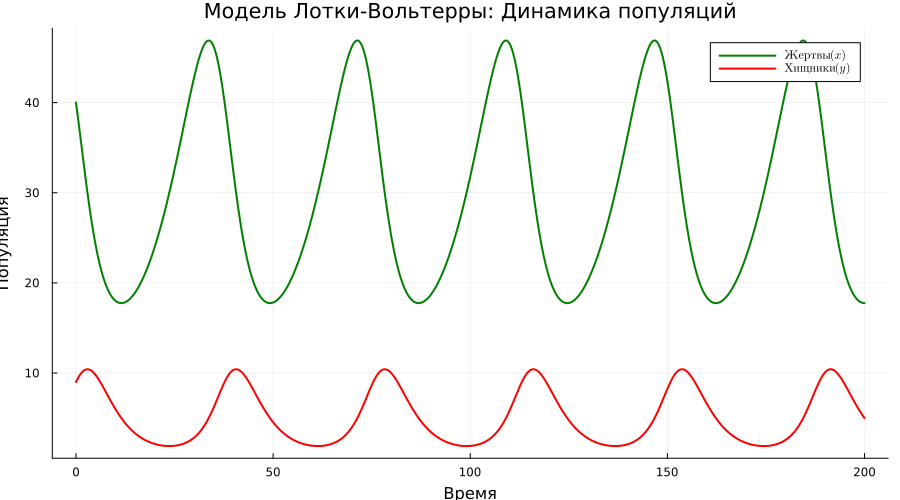

In [11]:
plt1 = plot(df_lv.t, [df_lv.prey df_lv.predator],
    label=[L"Жертвы (x)" L"Хищники (y)"],
    xlabel="Время",
    ylabel="Популяция",
    title="Модель Лотки-Вольтерры: Динамика популяций",
    linewidth=2,
    legend=:topright,
    grid=true,
    size=(900, 500),
    color=[:green :red])

Добавление стационарных уровней

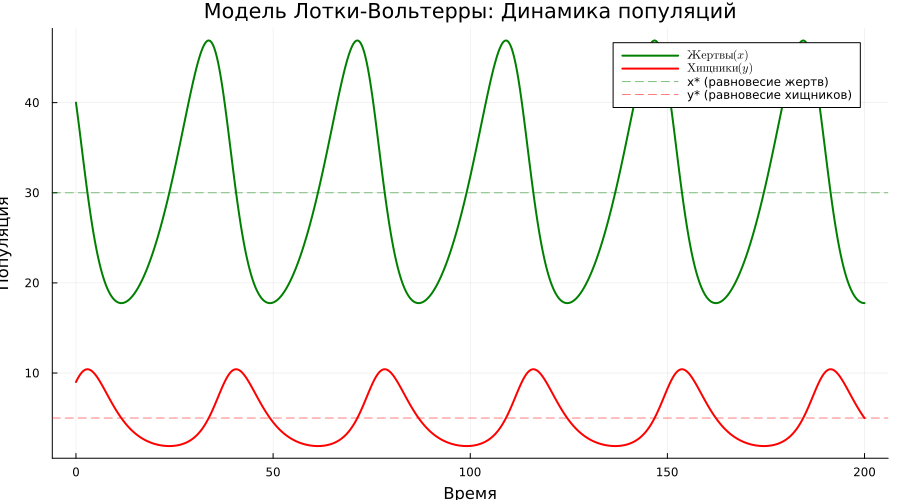

In [12]:
hline!(plt1, [x_star], color=:green, linestyle=:dash, alpha=0.5,
    label="x* (равновесие жертв)")
hline!(plt1, [y_star], color=:red, linestyle=:dash, alpha=0.5,
    label="y* (равновесие хищников)")

График 2: Фазовый портрет (хищники vs жертвы)

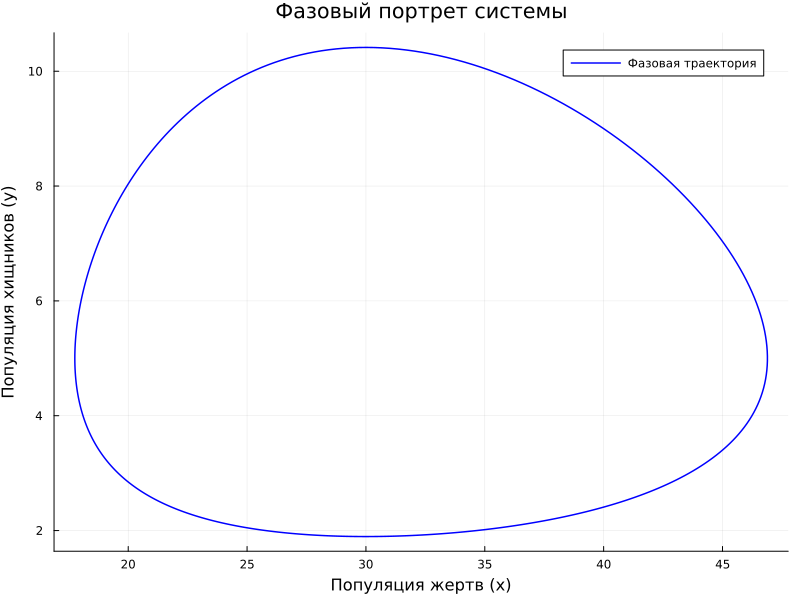

In [13]:
plt2 = plot(df_lv.prey, df_lv.predator,
    label="Фазовая траектория",
    xlabel="Популяция жертв (x)",
    ylabel="Популяция хищников (y)",
    title="Фазовый портрет системы",
    color=:blue,
    linewidth=1.5,
    grid=true,
    size=(800, 600),
    legend=:topright)

Добавление стрелок направления на фазовом портрете

In [14]:
step = 50 # шаг для отображения стрелок
for i in 1:step:length(df_lv.prey)-step
    plot!(plt2, [df_lv.prey[i], df_lv.prey[i+step]],
        [df_lv.predator[i], df_lv.predator[i+step]],
        arrow=:closed, color=:blue, alpha=0.3, label=false)
end

Добавление стационарной точки

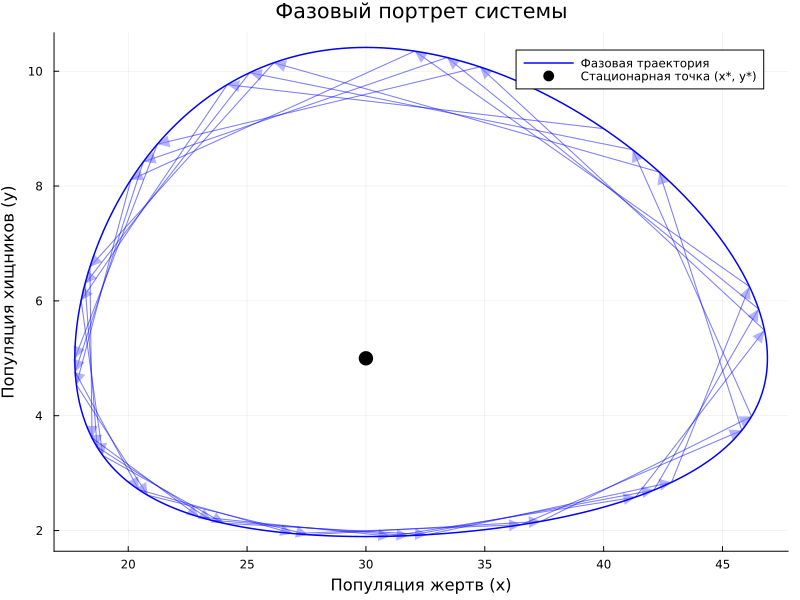

In [15]:
scatter!(plt2, [x_star], [y_star],
    color=:black, markersize=8, label="Стационарная точка (x*, y*)")

Изоклины (нулевого роста)

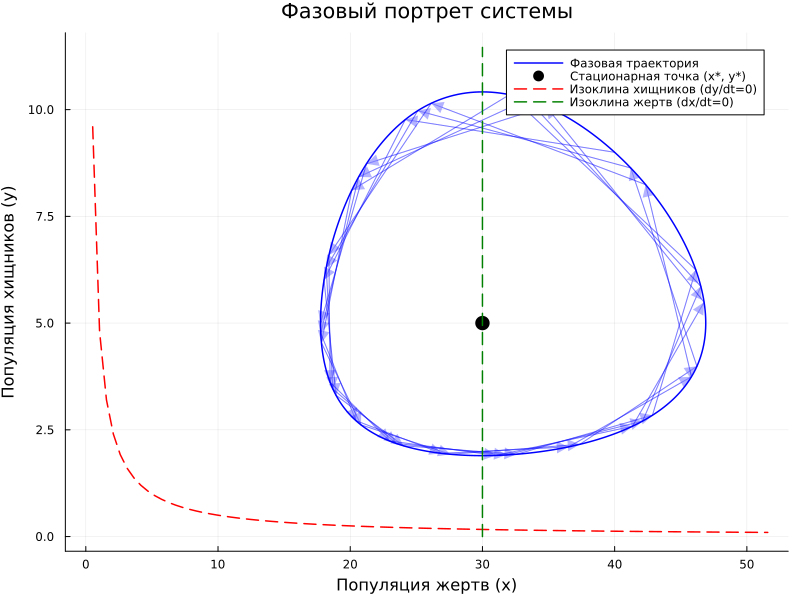

In [16]:
x_range = LinRange(0, maximum(df_lv.prey)*1.1, 100)
y_nullcline = p_lv[1] ./ (p_lv[2] .* x_range) # y-изоклина (dy/dt = 0)
plot!(plt2, x_range, y_nullcline,
    color=:red, linestyle=:dash, linewidth=1.5, label="Изоклина хищников (dy/dt=0)")

y_range = LinRange(0, maximum(df_lv.predator)*1.1, 100)
x_nullcline = fill(x_star, length(y_range)) # x-изоклина (dx/dt = 0) - вертикальная линия
plot!(plt2, x_nullcline, y_range,
    color=:green, linestyle=:dash, linewidth=1.5, label="Изоклина жертв (dx/dt=0)")

График 3: Производные (скорости изменения)

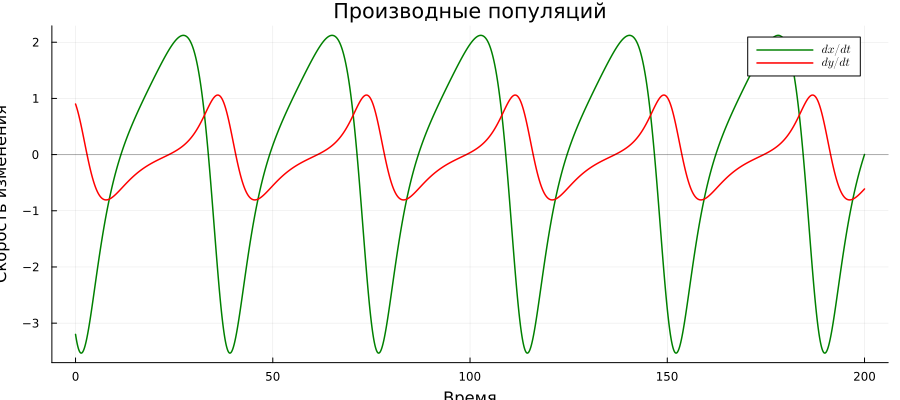

In [17]:
plt3 = plot(df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
    label=[L"dx/dt" L"dy/dt"],
    xlabel="Время",
    ylabel="Скорость изменения",
    title="Производные популяций",
    linewidth=1.5,
    legend=:topright,
    grid=true,
    size=(900, 400),
    color=[:green :red])
hline!(plt3, [0], color=:black, linestyle=:solid, alpha=0.3, label=false)

График 4: Относительные изменения (в %)

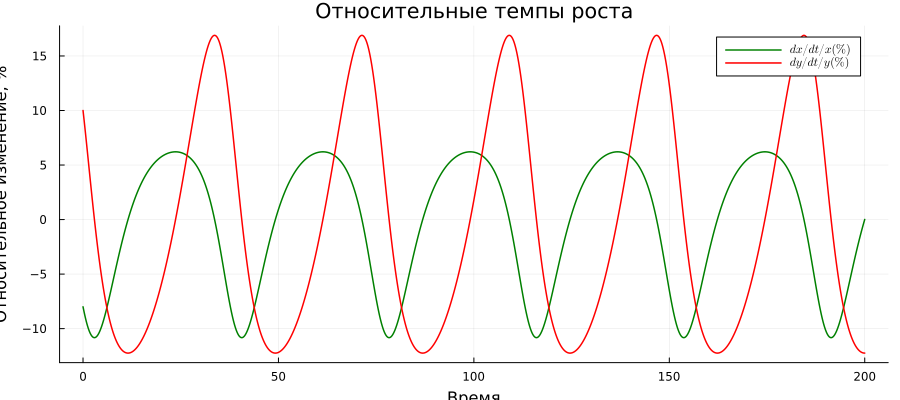

In [18]:
df_lv[!, :prey_pct_change] = df_lv.dprey_dt ./ df_lv.prey .* 100
df_lv[!, :predator_pct_change] = df_lv.dpredator_dt ./ df_lv.predator .* 100

plt4 = plot(df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
    label=[L"dx/dt / x (\%)" L"dy/dt / y (\%)"],
    xlabel="Время",
    ylabel="Относительное изменение, %",
    title="Относительные темпы роста",
    linewidth=1.5,
    legend=:topright,
    grid=true,
    size=(900, 400),
    color=[:green :red])

График 5: Спектральный анализ (быстрое преобразование Фурье)

In [32]:
function compute_fft(signal, dt)
    n = length(signal)
    spectrum = abs.(rfft(signal))
    freq = rfftfreq(n, 1/dt)
    spectrum = max.(spectrum, 1e-10)
    return freq, spectrum
end

compute_fft (generic function with 1 method)

In [33]:
freq_prey, spectrum_prey = compute_fft(df_lv.prey .- mean(df_lv.prey), dt_lv)
freq_predator, spectrum_predator = compute_fft(df_lv.predator .- mean(df_lv.predator), dt_lv)

([0.0, 0.04997501249375312, 0.09995002498750624, 0.14992503748125935, 0.19990004997501248, 0.24987506246876562, 0.2998500749625187, 0.34982508745627183, 0.39980009995002497, 0.4497751124437781  …  49.525237381309346, 49.5752123938031, 49.62518740629685, 49.6751624187906, 49.72513743128435, 49.775112443778106, 49.82508745627186, 49.87506246876561, 49.925037481259366, 49.97501249375312], [1.0e-10, 423.1802676967524, 475.58060350152135, 598.2330236807253, 935.0240427684812, 3516.201403867206, 1368.2902108708747, 467.3401357464074, 214.15765481300517, 73.8350806666066  …  1.9955537030705846, 1.9955094631005972, 1.9954701007659916, 1.9954356284404748, 1.9954061409450243, 1.9953814490155426, 1.99536184547309, 1.9953470500230188, 1.99533724188126, 1.9953322642682043])

Исключаем нулевую частоту для графика

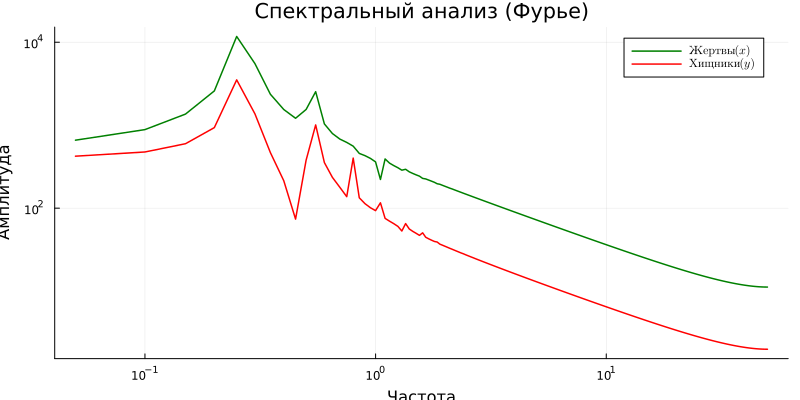

In [34]:
non_zero_idx = findall(freq_prey .> 0)

plt5 = plot(freq_prey[non_zero_idx], [spectrum_prey[non_zero_idx] spectrum_predator[non_zero_idx]],
    label=[L"Жертвы (x)" L"Хищники (y)"],
    xlabel="Частота",
    ylabel="Амплитуда",
    title="Спектральный анализ (Фурье)",
    linewidth=1.5,
    xscale=:log10,
    yscale=:log10,
    legend=:topright,
    grid=true,
    size=(800, 400),
    color=[:green :red])

Нахождение доминирующих частот

In [35]:
if length(spectrum_prey) > 2
    idx_prey = argmax(spectrum_prey[2:end]) + 1 # пропускаем нулевую частоту
    dominant_freq_prey = freq_prey[idx_prey]
    period_prey = 1/dominant_freq_prey
    println("\nДоминирующая частота колебаний жертв: ", round(dominant_freq_prey, digits=4), " Гц")
    println("Период колебаний жертв: ", round(period_prey, digits=2), " единиц времени")
end


Доминирующая частота колебаний жертв: 0.2499 Гц
Период колебаний жертв: 4.0 единиц времени


График 6: Компактная панель всех графиков

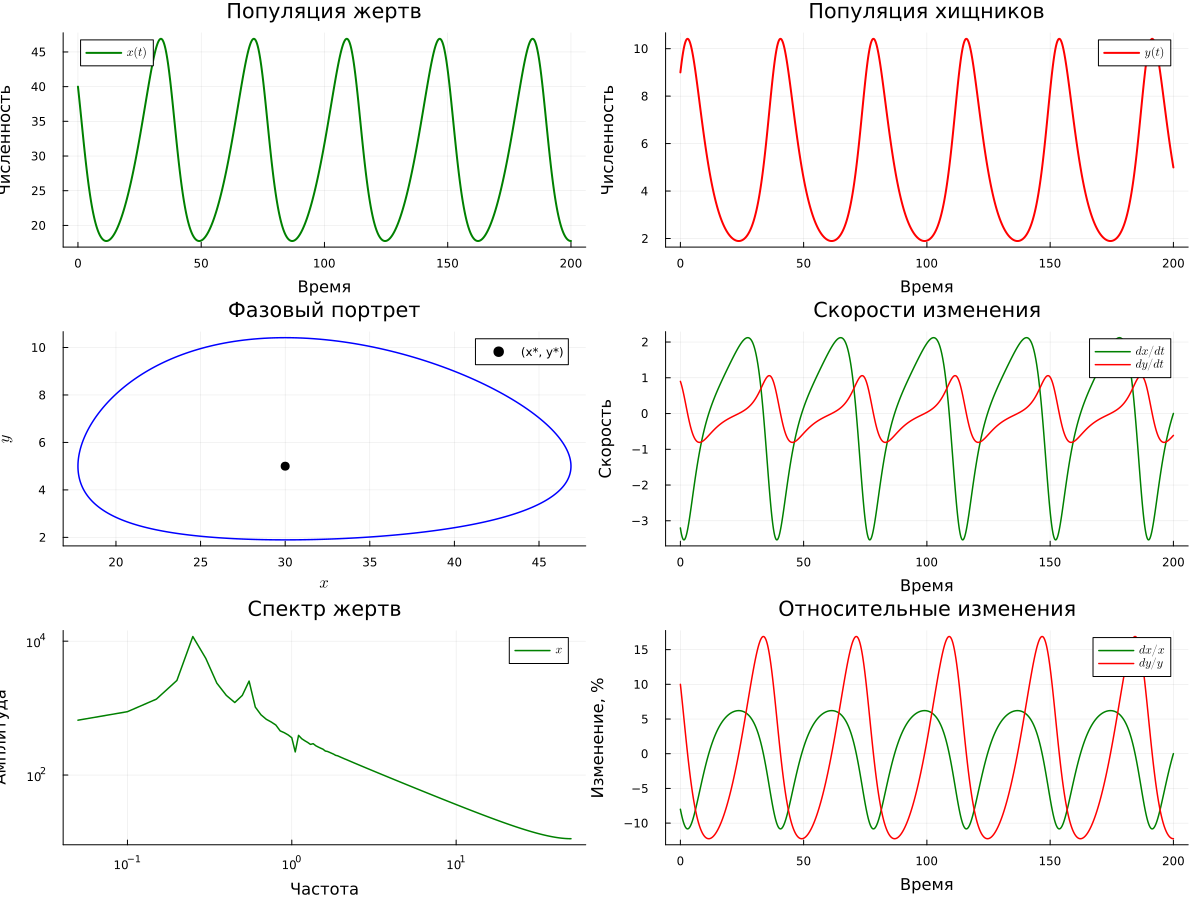

In [36]:
plt6 = plot(layout=(3, 2), size=(1200, 900))

plot!(plt6[1], df_lv.t, df_lv.prey, label=L"x(t)", color=:green, linewidth=2,
    title="Популяция жертв", grid=true, xlabel="Время", ylabel="Численность")
plot!(plt6[2], df_lv.t, df_lv.predator, label=L"y(t)", color=:red, linewidth=2,
    title="Популяция хищников", grid=true, xlabel="Время", ylabel="Численность")
plot!(plt6[3], df_lv.prey, df_lv.predator, label=false, color=:blue, linewidth=1.5,
    title="Фазовый портрет", xlabel=L"x", ylabel=L"y", grid=true)
scatter!(plt6[3], [x_star], [y_star], color=:black, markersize=5, label="(x*, y*)")
plot!(plt6[4], df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
    label=[L"dx/dt" L"dy/dt"], color=[:green :red], linewidth=1.5,
    title="Скорости изменения", grid=true, legend=:topright, xlabel="Время", ylabel="Скорость")
plot!(plt6[5], freq_prey[non_zero_idx], spectrum_prey[non_zero_idx],
    label=L"x", color=:green, linewidth=1.5,
    title="Спектр жертв", xscale=:log10, yscale=:log10, grid=true,
    xlabel="Частота", ylabel="Амплитуда")
plot!(plt6[6], df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
    label=[L"dx/x" L"dy/y"], color=[:green :red], linewidth=1.5,
    title="Относительные изменения", grid=true, legend=:topright,
    xlabel="Время", ylabel="Изменение, %")

Анализ результатов

In [37]:
println("\n" * "="^60)
println("Анализ результатов")
println("="^60)

println("\nОсновные статистики:")
println("Жертвы: min = ", round(minimum(df_lv.prey), digits=2),
    ", max = ", round(maximum(df_lv.prey), digits=2),
    ", mean = ", round(mean(df_lv.prey), digits=2))
println("Хищники: min = ", round(minimum(df_lv.predator), digits=2),
    ", max = ", round(maximum(df_lv.predator), digits=2),
    ", mean = ", round(mean(df_lv.predator), digits=2))


Анализ результатов

Основные статистики:
Жертвы: min = 17.75, max = 46.89, mean = 29.71
Хищники: min = 1.9, max = 10.41, mean = 5.2


Упрощенный анализ колебаний

In [38]:
function find_first_peak(signal, time)
    for i in 2:length(signal)-1
        if signal[i] > signal[i-1] && signal[i] > signal[i+1]
            return time[i], signal[i]
        end
    end
    return NaN, NaN
end

peak_time_prey, peak_value_prey = find_first_peak(df_lv.prey, df_lv.t)
peak_time_predator, peak_value_predator = find_first_peak(df_lv.predator, df_lv.t)

if !isnan(peak_time_prey) && !isnan(peak_time_predator)
    phase_shift = peak_time_predator - peak_time_prey
    println("\nАнализ колебаний:")
    println("Первый пик жертв: время = ", round(peak_time_prey, digits=2),
        ", значение = ", round(peak_value_prey, digits=2))
    println("Первый пик хищников: время = ", round(peak_time_predator, digits=2),
        ", значение = ", round(peak_value_predator, digits=2))
    println("Сдвиг фаз (хищники отстают): ", round(phase_shift, digits=2))
end


Анализ колебаний:
Первый пик жертв: время = 33.7, значение = 46.89
Первый пик хищников: время = 2.9, значение = 10.41
Сдвиг фаз (хищники отстают): -30.8


Сохранение графиков

In [39]:
savefig(plt1, plotsdir(script_name, "lv_dynamics.png"))
savefig(plt2, plotsdir(script_name, "lv_phase_portrait.png"))
savefig(plt3, plotsdir(script_name, "lv_derivatives.png"))
savefig(plt4, plotsdir(script_name, "lv_relative_changes.png"))
savefig(plt5, plotsdir(script_name, "lv_spectrum.png"))
savefig(plt6, plotsdir(script_name, "lv_panel.png"))

"/home/vvmalyuga/work/study/2026-1/2026-1==study--simulation-modeling/labs/lab02/project/plots/lv_panel.png"

Дополнительный анализ: чувствительность к параметрам

In [40]:
println("\n\n" * "="^60)
println("Анализ чувствительности")
println("="^60)



Анализ чувствительности


Функция для анализа влияния параметров

In [41]:
function analyze_parameter_sensitivity(param_index, values, param_name)
    println("\nАнализ чувствительности к параметру: ", param_name)
    results = []
    for val in values
        p_test = copy(p_lv)
        p_test[param_index] = val
        prob_test = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_test)
        sol_test = solve(prob_test, Tsit5(), saveat=1.0)
        prey_end = sol_test.u[end][1]
        predator_end = sol_test.u[end][2]
        push!(results, (param=val, prey=prey_end, predator=predator_end))
        println("  $(param_name)=$(val): жертвы=$(round(prey_end; digits=2)), хищники=$(round(predator_end; digits=2))")
    end
    return results
end

analyze_parameter_sensitivity (generic function with 1 method)

Анализ чувствительности к ключевым параметрам

In [42]:
println("\n1. Влияние скорости размножения жертв (α):")
analyze_parameter_sensitivity(1, [0.05, 0.1, 0.2, 0.3], "α")

println("\n2. Влияние смертности хищников (γ):")
analyze_parameter_sensitivity(4, [0.1, 0.3, 0.5, 0.7], "γ")

println("\nМоделирование завершено успешно!")


1. Влияние скорости размножения жертв (α):

Анализ чувствительности к параметру: α
  α=0.05: жертвы=16.29, хищники=0.63
  α=0.1: жертвы=17.92, хищники=4.95
  α=0.2: жертвы=26.76, хищники=6.9
  α=0.3: жертвы=33.95, хищники=24.39

2. Влияние смертности хищников (γ):

Анализ чувствительности к параметру: γ
  γ=0.1: жертвы=0.87, хищники=2.07
  γ=0.3: жертвы=17.92, хищники=4.95
  γ=0.5: жертвы=54.61, хищники=10.01
  γ=0.7: жертвы=101.41, хищники=1.41

Моделирование завершено успешно!
